# 01 - Train Detector (Stage 1)
Notebook pentru experimentele A1/A2/A3 cu YOLOv8 detector single-class trash.

In [1]:
import sys
from pathlib import Path

import torch
from ultralytics import YOLO

REPO_ROOT = Path('../..').resolve()
print('REPO_ROOT:', REPO_ROOT)
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

REPO_ROOT: D:\TrashDetectionSystem
Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [ ]:
# Config stabil pe Windows + GPU RTX 3050
DATA_YAML      = str(REPO_ROOT / 'datasets' / 'parks_detect' / 'parks_detect.yaml')
DATA_YAML_FULL = str(REPO_ROOT / 'datasets' / 'parks_detect_full' / 'dataset.yaml')
BASE_MODEL = 'yolov8n.pt'
EPOCHS = 150
IMGSZ = 416
BATCH = 8
PATIENCE = 30
WORKERS = 0
SEED = 42
DEVICE = '0'
CACHE = False
RESUME = False
RUN_NAME = 'parks-trash-A2'
PROJECT = None

print(DATA_YAML)


D:\TrashDetectionSystem\datasets\parks_detect\parks_detect.yaml


In [3]:
import yaml

data_path = Path(DATA_YAML)
assert data_path.exists(), f'Missing YAML: {data_path}'

with data_path.open('r', encoding='utf-8') as f:
    ds = yaml.safe_load(f)

root = Path(ds['path'])
if not root.is_absolute():
    root = (data_path.parent / root).resolve()

for split in ('train', 'val', 'test'):
    d = root / ds.get(split, split)
    n = len(list(d.glob('*.jpg'))) + len(list(d.glob('*.png')))
    print(split, n, d)

print('classes:', ds['names'])

train 34 D:\TrashDetectionSystem\datasets\parks_detect\images\train
val 7 D:\TrashDetectionSystem\datasets\parks_detect\images\val
test 7 D:\TrashDetectionSystem\datasets\parks_detect\images\test
classes: {0: 'trash'}


In [4]:
model = YOLO(BASE_MODEL)

train_kwargs = dict(
    data=DATA_YAML, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, workers=WORKERS,
    patience=PATIENCE, name=RUN_NAME, seed=SEED, cache=CACHE, resume=RESUME
)
if DEVICE is not None:
    train_kwargs['device'] = DEVICE
if PROJECT is not None:
    train_kwargs['project'] = PROJECT

results = model.train(**train_kwargs)
save_dir = Path(getattr(results, 'save_dir', 'runs/detect/'))
print('save_dir:', save_dir)
print('best:', save_dir / 'weights' / 'best.pt')

New https://pypi.org/project/ultralytics/8.4.24 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\TrashDetectionSystem\datasets\parks_detect\parks_detect.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0

In [5]:
vr = model.val(data=DATA_YAML, imgsz=IMGSZ, batch=BATCH, split='val',
               device=DEVICE, workers=WORKERS)
box = getattr(vr, 'box', None)
if box is not None:
    print('P       :', float(box.mp))
    print('R       :', float(box.mr))
    print('mAP50   :', float(box.map50))
    print('mAP50-95:', float(box.map))


Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1942.2128.0 MB/s, size: 2572.9 KB)
val: Scanning D:\TrashDetectionSystem\datasets\parks_detect\labels\val.cache... 7 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7/7  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.3s/it 1.3s
                   all          7          4          1      0.455      0.509      0.269
Speed: 1.2ms preprocess, 25.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to D:\TrashDetectionSystem\runs\detect\val6
P       : 1.0
R       : 0.4549446682805123
mAP50   : 0.509350533979645
mAP50-95: 0.26885818640041714


In [ ]:
# Optional: ruleaza toate experimentele A1/A2/A22/A3
EXPERIMENTS = [
    ('A1',  'yolov8n.pt', 100, DATA_YAML,      'parks-trash-A1'),
    ('A2',  'yolov8n.pt', 150, DATA_YAML,      'parks-trash-A2'),
    ('A22', 'yolov8n.pt', 150, DATA_YAML_FULL, 'parks-trash-A22'),
    ('A3',  'yolov8s.pt', 150, DATA_YAML_FULL, 'parks-trash-A3'),
]

exp_results = {}
for exp_id, base_model, num_epochs, data_yaml, run_name in EXPERIMENTS:
    print('\n' + '=' * 60)
    print(f'EXPERIMENT {exp_id}: {base_model} epochs={num_epochs} run={run_name}')
    print('=' * 60)

    m = YOLO(base_model)
    r = m.train(
        data=data_yaml, epochs=num_epochs, imgsz=IMGSZ, batch=BATCH,
        workers=WORKERS, patience=PATIENCE, name=run_name, seed=SEED,
        cache=CACHE, device=DEVICE
    )
    vr = m.val(data=data_yaml, imgsz=IMGSZ, batch=BATCH, split='val',
               device=DEVICE, workers=WORKERS)
    box = getattr(vr, 'box', None)
    sd = Path(getattr(r, 'save_dir', ''))
    exp_results[exp_id] = {
        'run_name': run_name,
        'save_dir': str(sd),
        'best_pt': str(sd / 'weights' / 'best.pt') if str(sd) else '',
        'P': float(box.mp) if box else None,
        'R': float(box.mr) if box else None,
        'mAP50': float(box.map50) if box else None,
        'mAP5095': float(box.map) if box else None,
    }

exp_results


EXPERIMENT A1: yolov8n.pt epochs=100 run=parks-trash-A1
New https://pypi.org/project/ultralytics/8.4.24 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\TrashDetectionSystem\datasets\parks_detect\parks_detect.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det

{'A1': {'run_name': 'parks-trash-A1',
  'save_dir': 'D:\\TrashDetectionSystem\\runs\\detect\\parks-trash-A19',
  'best_pt': 'D:\\TrashDetectionSystem\\runs\\detect\\parks-trash-A19\\weights\\best.pt',
  'P': 0.002347417840375587,
  'R': 1.0,
  'mAP50': 0.007240021008403362,
  'mAP5095': 0.004250301732998611},
 'A2': {'run_name': 'parks-trash-A2',
  'save_dir': 'D:\\TrashDetectionSystem\\runs\\detect\\parks-trash-A23',
  'best_pt': 'D:\\TrashDetectionSystem\\runs\\detect\\parks-trash-A23\\weights\\best.pt',
  'P': 1.0,
  'R': 0.4549446682805123,
  'mAP50': 0.509350533979645,
  'mAP5095': 0.26885818640041714},
 'A3': {'run_name': 'parks-trash-A3',
  'save_dir': 'D:\\TrashDetectionSystem\\runs\\detect\\parks-trash-A32',
  'best_pt': 'D:\\TrashDetectionSystem\\runs\\detect\\parks-trash-A32\\weights\\best.pt',
  'P': 0.07926195030159541,
  'R': 0.25,
  'mAP50': 0.13402805949966196,
  'mAP5095': 0.08081874013973407}}

# 01 — Antrenare Detector (Stage 1)

Antrenează un **detector YOLOv8 single-class `trash`** pe dataset-ul de parcuri.

## Experimente planificate (conform EXPERIMENT_PLAN.md)

| ID | Model    | imgsz | epochs | Dataset         | Scop                          |
|----|----------|-------|--------|-----------------|-------------------------------|
| A1 | yolov8n  | 640   | 100    | 48-img quick    | Sanity check, test pipeline   |
| A2 | yolov8n  | 640   | 150    | Full dataset    | Baseline principal            |
| A3 | yolov8s  | 640   | 150    | Full dataset    | Model mai mare — comparație   |

**Pre-condiție**: Ai rulat `01_data_preparation.ipynb` (split + validare dataset).

In [ ]:
import sys
from pathlib import Path

REPO_ROOT = Path("../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ultralytics import YOLO

print(f"Rădăcina proiectului: {REPO_ROOT}")

Rădăcina proiectului: D:\TrashDetectionSystem


In [ ]:
# ── CONFIG — schimbă parametrii pentru fiecare experiment ─────────────────────

# Dataset
DATA_YAML      = str(REPO_ROOT / "datasets" / "parks_detect" / "parks_detect.yaml")
DATA_YAML_FULL = str(REPO_ROOT / "datasets" / "parks_detect_full" / "dataset.yaml")  # TACO+parks (1548 img)

# Model de bază
BASE_MODEL   = "yolov8n.pt"   # A1/A2/A22: yolov8n.pt | A3: yolov8s.pt

# Hiperparametri
EPOCHS       = 100            # A1: 100 | A2/A22/A3: 150
IMGSZ        = 640            # GPU: 640 standard
BATCH        = 16             # RTX 3050 4GB: 16 OK; scade la 8 dacă apare OOM
PATIENCE     = 30             # early stopping
WORKERS      = 0              # Windows+Jupyter: trebuie 0 (multiprocessing incompatibil cu notebook)
SEED         = 42
DEVICE       = "0"            # GPU 0 = RTX 3050
CACHE        = False
RESUME       = False          # True = continuă ultimul run întrerupt

# Identificare run
RUN_NAME     = "parks-trash-A1"  # schimbă: parks-trash-A1, A2, A22, A3
PROJECT      = None              # None = Ultralytics default (runs/detect/)

print(f"Model: {BASE_MODEL}  |  Date: {Path(DATA_YAML).name}")
print(f"Epochs: {EPOCHS}  |  imgsz: {IMGSZ}  |  batch: {BATCH}")
print(f"Run: {RUN_NAME}")

Model: yolov8n.pt  |  Date: parks_detect.yaml
Epochs: 100  |  imgsz: 640  |  batch: 16
Run: parks-trash-A1


---
## Verificare pre-antrenare
Verifică că dataset-ul YAML există și că split-urile au imagini.

In [ ]:
import yaml

data_path = Path(DATA_YAML)
assert data_path.exists(), f"YAML nu există: {data_path}"

with data_path.open() as f:
    ds = yaml.safe_load(f)

root = Path(ds["path"])
if not root.is_absolute():
    root = data_path.parent / root

for split in ("train", "val"):
    d = root / ds.get(split, split)
    imgs = list(d.glob("*.jpg")) + list(d.glob("*.png"))
    print(f"Split {split}: {len(imgs)} imagini  →  {d}")

print(f"\nClase: {ds['names']}")
print("\n[OK] Dataset verificat. Poți rula antrenarea.")

Split train: 34 imagini  →  D:\TrashDetectionSystem\datasets\parks_detect\images\train
Split val: 7 imagini  →  D:\TrashDetectionSystem\datasets\parks_detect\images\val

Clase: {0: 'trash'}

[OK] Dataset verificat. Poți rula antrenarea.


---
## Antrenare

> **Atenție**: Antrenarea poate dura câteva minute până la ore în funcție de hardware.  
> Progresul va fi afișat în output-ul celulei de mai jos.

In [ ]:
model = YOLO(BASE_MODEL)

train_kwargs = dict(
    data      = DATA_YAML,
    epochs    = EPOCHS,
    imgsz     = IMGSZ,
    batch     = BATCH,
    workers   = WORKERS,
    patience  = PATIENCE,
    name      = RUN_NAME,
    seed      = SEED,
    cache     = CACHE,
    resume    = RESUME,
)
if DEVICE is not None:
    train_kwargs["device"] = DEVICE
if PROJECT is not None:
    train_kwargs["project"] = PROJECT

results = model.train(**train_kwargs)

save_dir = Path(getattr(results, "save_dir", "runs/detect/"))
best_weights = save_dir / "weights" / "best.pt"
print(f"\n[DONE] Artifacts: {save_dir}")
print(f"Best weights  : {best_weights}")

New https://pypi.org/project/ultralytics/8.4.24 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\TrashDetectionSystem\datasets\parks_detect\parks_detect.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=

---
## Validare rapidă pe val-split
Rulează validarea pe splitului de validare imediat după antrenare.

In [1]:
val_results = model.val(
    data   = DATA_YAML,
    imgsz  = IMGSZ,
    batch  = BATCH,
    split  = "val",
    device = DEVICE,
)

box = getattr(val_results, "box", None)
if box:
    print(f"Precision : {box.mp:.4f}")
    print(f"Recall    : {box.mr:.4f}")
    print(f"mAP@50    : {box.map50:.4f}")
    print(f"mAP@50-95 : {box.map:.4f}")

NameError: name 'model' is not defined

---
## Curbe de antrenare
Ultralytics salvează automat `results.png` și CSV cu metricile per epocă. Afișăm graficul here.

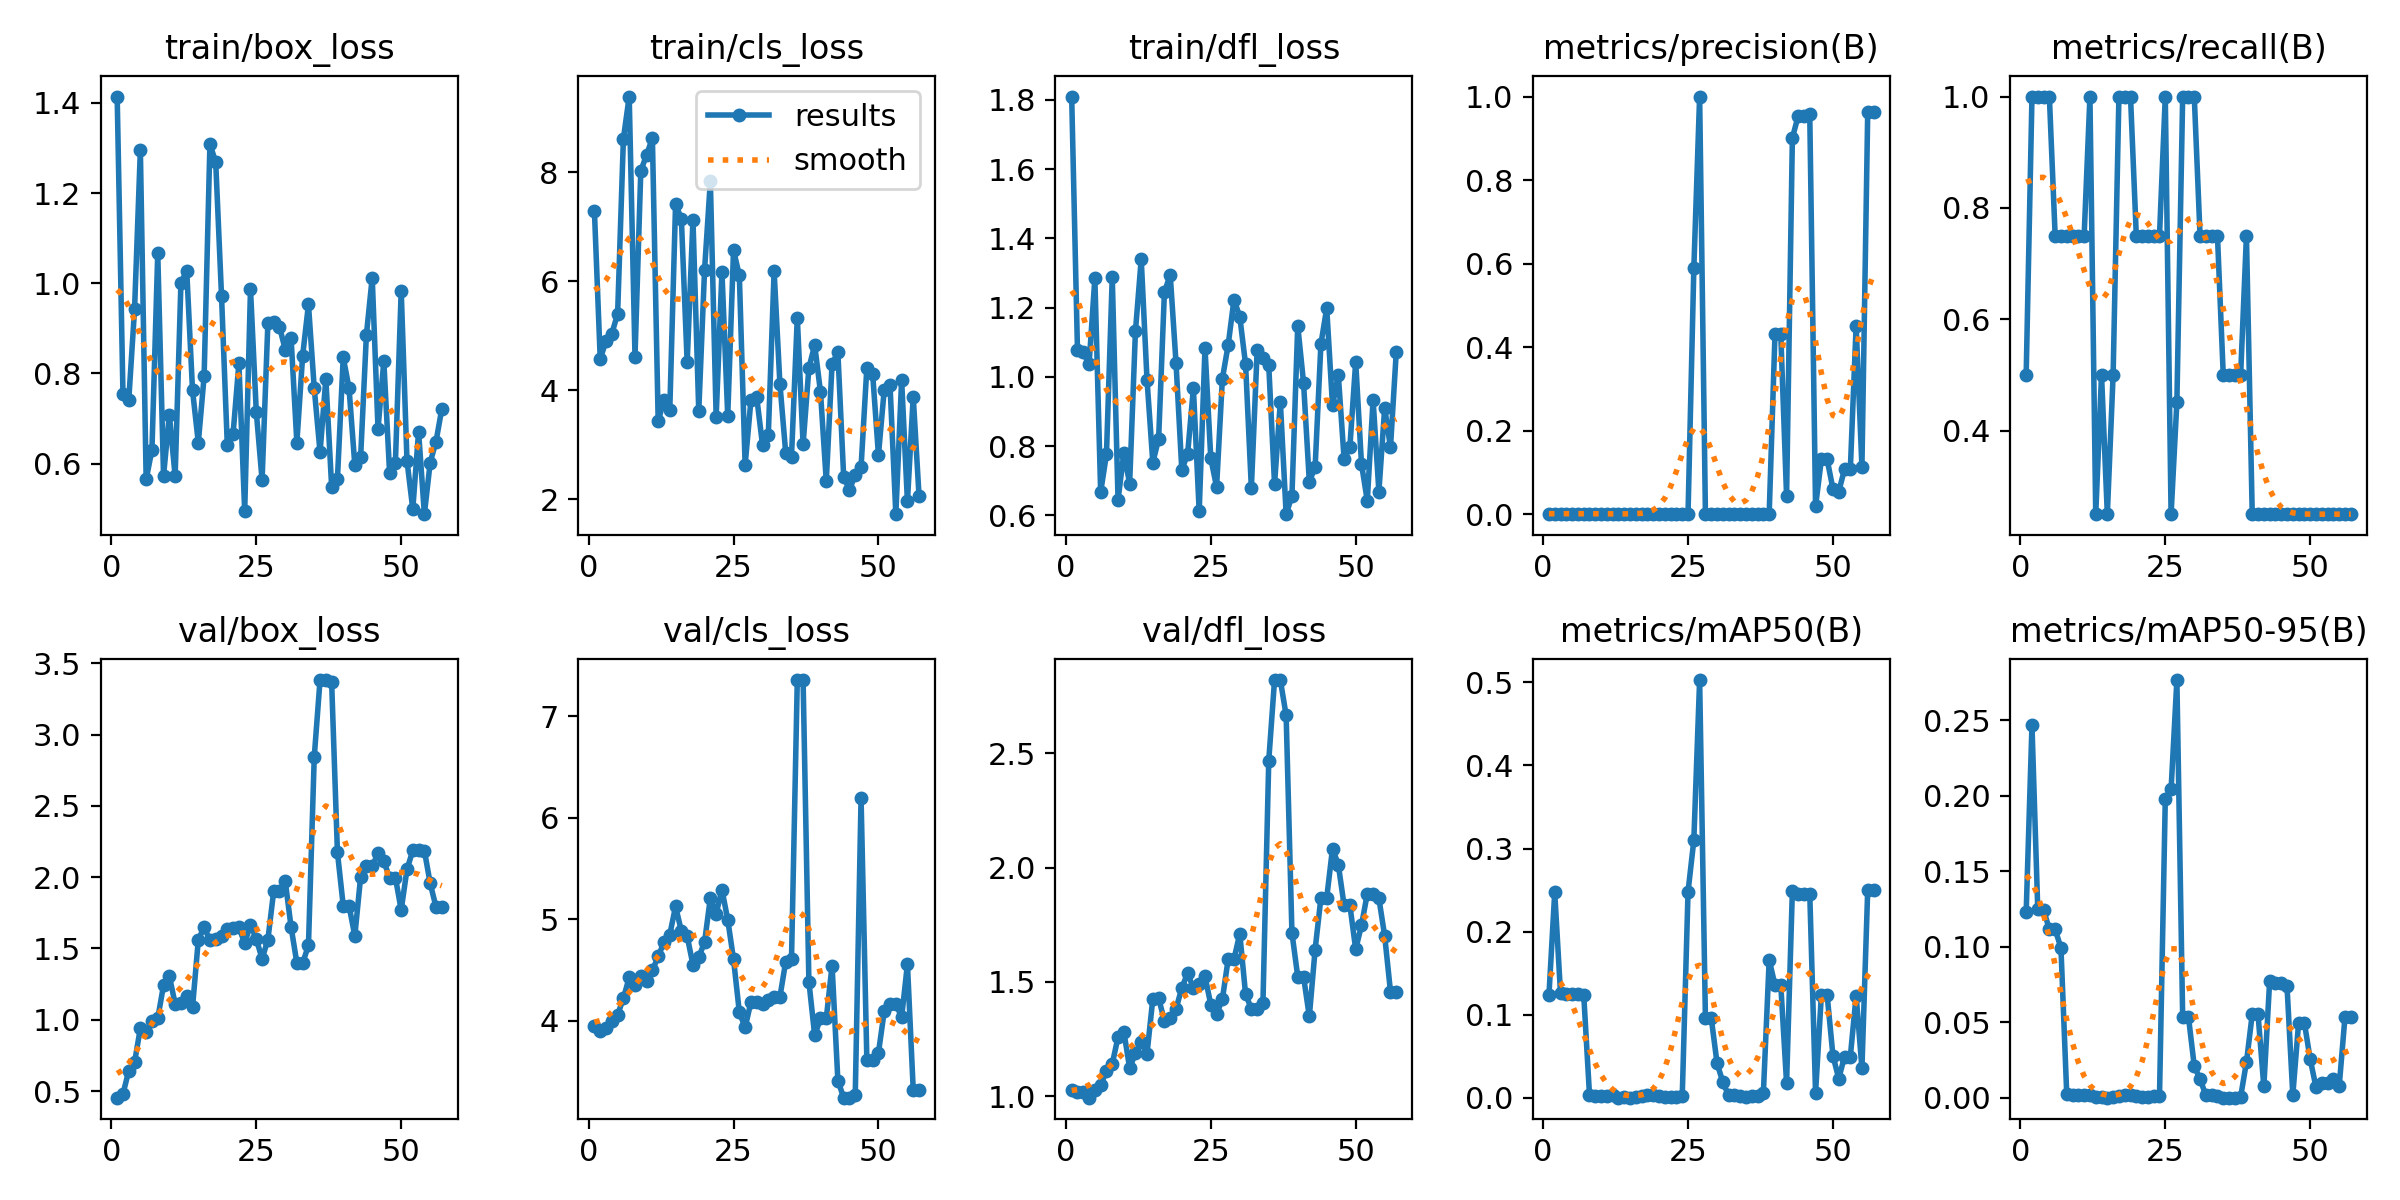

In [ ]:
from IPython.display import Image as IPImage, display

results_png = save_dir / "results.png"
if results_png.exists():
    display(IPImage(str(results_png)))
else:
    print(f"Fișierul results.png nu a fost găsit în {save_dir}")

---
## Experimente multiple (combinare automată)
Rulează codul de mai jos pentru a antrena toate experimentele definite în lista `EXPERIMENTS`.

In [1]:
EXPERIMENTS = [
    # (id,   model,        epochs, data_yaml,       run_name)
    ("A1",  "yolov8n.pt", 100, DATA_YAML,      "parks-trash-A1"),
    ("A2",  "yolov8n.pt", 150, DATA_YAML,      "parks-trash-A2"),
    ("A22", "yolov8n.pt", 150, DATA_YAML_FULL, "parks-trash-A22"),
    ("A3",  "yolov8s.pt", 150, DATA_YAML_FULL, "parks-trash-A3"),
]

exp_results = {}

for exp_id, base_model, num_epochs, data_yaml, run_name in EXPERIMENTS:
    print(f"\n{'='*60}")
    print(f"EXPERIMENT {exp_id}: {base_model}  epochs={num_epochs}  run={run_name}")
    print('=' * 60)

    m = YOLO(base_model)
    r = m.train(
        data=data_yaml,
        epochs=num_epochs,
        imgsz=IMGSZ,
        batch=BATCH,
        workers=WORKERS,
        patience=PATIENCE,
        name=run_name,
        seed=SEED,
        cache=CACHE,
        device=DEVICE,
    )

    vr = m.val(
        data=data_yaml,
        imgsz=IMGSZ,
        batch=BATCH,
        split="val",
        device=DEVICE,
        workers=WORKERS,
    )
    box = getattr(vr, "box", None)
    sd = Path(getattr(r, "save_dir", ""))

    exp_results[exp_id] = {
        "run_name": run_name,
        "save_dir": str(sd),
        "best_pt": str(sd / "weights" / "best.pt") if str(sd) else "",
        "P": float(box.mp) if box else None,
        "R": float(box.mr) if box else None,
        "mAP50": float(box.map50) if box else None,
        "mAP5095": float(box.map) if box else None,
    }

    P = exp_results[exp_id]["P"]
    R = exp_results[exp_id]["R"]
    m50 = exp_results[exp_id]["mAP50"]
    if P is not None and R is not None and m50 is not None:
        print(f"  P={P:.4f}  R={R:.4f}  mAP50={m50:.4f}")
    else:
        print("  Metrics unavailable for this run")

# Tabel sumar
print(f"\n{'ID':<4} {'Model':<12} {'Epochs':>6} {'P':>7} {'R':>7} {'mAP50':>8} {'mAP5095':>9}")
print("-" * 60)
for exp_id, base_model, num_epochs, _, _ in EXPERIMENTS:
    er = exp_results.get(exp_id, {})
    P = er.get('P')
    R = er.get('R')
    m50 = er.get('mAP50')
    m5095 = er.get('mAP5095')
    fmt = lambda v: f"{v:.4f}" if v is not None else "    -"
    print(f"{exp_id:<4} {base_model:<12} {num_epochs:>6} {fmt(P):>7} {fmt(R):>7} {fmt(m50):>8} {fmt(m5095):>9}")

exp_results

NameError: name 'DATA_YAML' is not defined